In [ ]:
import copy
import io
import random
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings("ignore")

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.11.0+cu128
CUDA available: True


In [ ]:
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [ ]:
TEXT = """
Next character prediction is a fundamental task in the field of natural language
processing (NLP) that involves predicting the next character in a sequence of text
based on the characters that precede it. This task is essential for various
applications, including text auto-completion, spell checking, and even in the
development of sophisticated AI models capable of generating human-like text.

At its core, next character prediction relies on statistical models or deep learning
algorithms to analyze a given sequence of text and predict which character is most
likely to follow. These predictions are based on patterns and relationships learned
from large datasets of text during the training phase of the model.

One of the most popular approaches to next character prediction involves the use of
Recurrent Neural Networks (RNNs), and more specifically, a variant called Long
Short-Term Memory (LSTM) networks. RNNs are particularly well-suited for sequential
data like text, as they can maintain information in 'memory' about previous characters
to inform the prediction of the next character. LSTM networks enhance this capability
by being able to remember long-term dependencies, making them even more effective for
next character prediction tasks.

Training a model for next character prediction involves feeding it large amounts of
text data, allowing it to learn the probability of each character's appearance
following a sequence of characters. During this training process, the model adjusts
its parameters to minimize the difference between its predictions and the actual
outcomes, thus improving its predictive accuracy over time.

Once trained, the model can be used to predict the next character in a given piece of
text by considering the sequence of characters that precede it. This can enhance user
experience in text editing software, improve efficiency in coding environments with
auto-completion features, and enable more natural interactions with AI-based chatbots
and virtual assistants.

In summary, next character prediction plays a crucial role in enhancing the
capabilities of various NLP applications, making text-based interactions more
efficient, accurate, and human-like. Through the use of advanced machine learning
models like RNNs and LSTMs, next character prediction continues to evolve, opening new
possibilities for the future of text-based technology.
"""

# Replace line breaks and repeated spaces with normal single spaces.
TEXT = " ".join(TEXT.split())

print("Number of characters:", len(TEXT))
print("\nBeginning of the text:\n")
print(TEXT[:500])

Number of characters: 2386

Beginning of the text:

Next character prediction is a fundamental task in the field of natural language processing (NLP) that involves predicting the next character in a sequence of text based on the characters that precede it. This task is essential for various applications, including text auto-completion, spell checking, and even in the development of sophisticated AI models capable of generating human-like text. At its core, next character prediction relies on statistical models or deep learning algorithms to analy


In [ ]:
characters = sorted(list(set(TEXT)))

char_to_index = {
    character: index
    for index, character in enumerate(characters)
}

index_to_char = {
    index: character
    for character, index in char_to_index.items()
}

encoded_text = torch.tensor(
    [char_to_index[character] for character in TEXT],
    dtype=torch.long
)

vocab_size = len(characters)

print("Vocabulary size:", vocab_size)
print("Characters:")
print(characters)
print("\nFirst 40 encoded values:")
print(encoded_text[:40])

Vocabulary size: 44
Characters:
[' ', "'", '(', ')', ',', '-', '.', 'A', 'D', 'I', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']

First 40 encoded values:
tensor([12, 22, 41, 37,  0, 20, 25, 18, 35, 18, 20, 37, 22, 35,  0, 33, 35, 22,
        21, 26, 20, 37, 26, 32, 31,  0, 26, 36,  0, 18,  0, 23, 38, 31, 21, 18,
        30, 22, 31, 37])


In [ ]:
split_index = int(0.80 * len(encoded_text))

train_encoded = encoded_text[:split_index]
validation_encoded = encoded_text[split_index:]

print("Total characters:", len(encoded_text))
print("Training characters:", len(train_encoded))
print("Validation characters:", len(validation_encoded))
print("Training percentage:", len(train_encoded) / len(encoded_text) * 100)
print("Validation percentage:", len(validation_encoded) / len(encoded_text) * 100)

Total characters: 2386
Training characters: 1908
Validation characters: 478
Training percentage: 79.96647108130763
Validation percentage: 20.033528918692372


In [ ]:
class CharacterWindowDataset(Dataset):
    def __init__(self, encoded_data, sequence_length):
        self.encoded_data = encoded_data
        self.sequence_length = sequence_length

    def __len__(self):
        return len(self.encoded_data) - self.sequence_length

    def __getitem__(self, index):
        input_sequence = self.encoded_data[
            index:index + self.sequence_length
        ]

        target_character = self.encoded_data[
            index + self.sequence_length
        ]

        return input_sequence, target_character


def create_loaders(sequence_length, batch_size=32):
    train_dataset = CharacterWindowDataset(
        train_encoded,
        sequence_length
    )

    validation_dataset = CharacterWindowDataset(
        validation_encoded,
        sequence_length
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0
    )

    validation_loader = DataLoader(
        validation_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )

    return train_loader, validation_loader

In [ ]:
example_sequence_length = 10

example_dataset = CharacterWindowDataset(
    train_encoded,
    example_sequence_length
)

example_input, example_target = example_dataset[0]

input_text = "".join(
    index_to_char[index.item()]
    for index in example_input
)

target_text = index_to_char[example_target.item()]

print("Input sequence:", repr(input_text))
print("Correct next character:", repr(target_text))

Input sequence: 'Next chara'
Correct next character: 'c'


In [ ]:
class CharacterTransformer(nn.Module):
    def __init__(
        self,
        vocab_size,
        d_model=64,
        number_of_heads=2,
        number_of_layers=2,
        feedforward_size=128,
        dropout=0.10,
        maximum_sequence_length=50
    ):
        super().__init__()

        self.maximum_sequence_length = maximum_sequence_length
        self.d_model = d_model
        self.number_of_heads = number_of_heads
        self.number_of_layers = number_of_layers
        self.feedforward_size = feedforward_size

        self.character_embedding = nn.Embedding(
            vocab_size,
            d_model
        )

        self.position_embedding = nn.Embedding(
            maximum_sequence_length,
            d_model
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=number_of_heads,
            dim_feedforward=feedforward_size,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=number_of_layers
        )

        self.final_normalization = nn.LayerNorm(d_model)

        self.output_layer = nn.Linear(
            d_model,
            vocab_size
        )

    def forward(self, input_sequence):
        batch_size, sequence_length = input_sequence.shape

        if sequence_length > self.maximum_sequence_length:
            raise ValueError(
                f"Sequence length {sequence_length} exceeds "
                f"maximum length {self.maximum_sequence_length}."
            )

        positions = torch.arange(
            sequence_length,
            device=input_sequence.device
        ).unsqueeze(0)

        character_vectors = self.character_embedding(input_sequence)
        position_vectors = self.position_embedding(positions)

        hidden_states = character_vectors + position_vectors

        hidden_states = self.transformer_encoder(hidden_states)

        # Use the representation of the final input character.
        final_hidden_state = hidden_states[:, -1, :]

        final_hidden_state = self.final_normalization(
            final_hidden_state
        )

        logits = self.output_layer(final_hidden_state)

        return logits

In [ ]:
test_model = CharacterTransformer(
    vocab_size=vocab_size
).to(device)

test_input = torch.randint(
    low=0,
    high=vocab_size,
    size=(8, 10)
).to(device)

test_output = test_model(test_input)

print("Input shape:", test_input.shape)
print("Output shape:", test_output.shape)

assert test_output.shape == (8, vocab_size)

print("Model test passed.")

Input shape: torch.Size([8, 10])
Output shape: torch.Size([8, 44])
Model test passed.


In [ ]:
def count_trainable_parameters(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )


parameter_count = count_trainable_parameters(test_model)

print(f"Trainable parameters: {parameter_count:,}")

Trainable parameters: 75,948


In [ ]:
@torch.no_grad()
def evaluate_model(model, data_loader, loss_function):
    model.eval()

    total_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    for input_sequences, target_characters in data_loader:
        input_sequences = input_sequences.to(device)
        target_characters = target_characters.to(device)

        logits = model(input_sequences)

        loss = loss_function(
            logits,
            target_characters
        )

        total_loss += (
            loss.item() * input_sequences.size(0)
        )

        predicted_characters = logits.argmax(dim=1)

        correct_predictions += (
            predicted_characters == target_characters
        ).sum().item()

        total_predictions += target_characters.size(0)

    average_loss = total_loss / total_predictions
    accuracy = correct_predictions / total_predictions

    return average_loss, accuracy

In [ ]:
def synchronize_device():
    if torch.cuda.is_available():
        torch.cuda.synchronize()


def train_transformer(
    sequence_length,
    epochs=150,
    batch_size=32,
    learning_rate=0.001,
    d_model=64,
    number_of_heads=2,
    number_of_layers=2,
    feedforward_size=128,
    dropout=0.10
):
    set_seed()

    train_loader, validation_loader = create_loaders(
        sequence_length=sequence_length,
        batch_size=batch_size
    )

    model = CharacterTransformer(
        vocab_size=vocab_size,
        d_model=d_model,
        number_of_heads=number_of_heads,
        number_of_layers=number_of_layers,
        feedforward_size=feedforward_size,
        dropout=dropout,
        maximum_sequence_length=50
    ).to(device)

    loss_function = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=1e-4
    )

    history = {
        "training_loss": [],
        "training_accuracy": [],
        "validation_loss": [],
        "validation_accuracy": []
    }

    best_validation_loss = float("inf")
    best_epoch = 0
    best_model_state = None

    synchronize_device()
    training_start = time.perf_counter()

    for epoch in range(1, epochs + 1):
        model.train()

        total_training_loss = 0.0
        correct_training_predictions = 0
        total_training_predictions = 0

        for input_sequences, target_characters in train_loader:
            input_sequences = input_sequences.to(device)
            target_characters = target_characters.to(device)

            optimizer.zero_grad()

            logits = model(input_sequences)

            loss = loss_function(
                logits,
                target_characters
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            optimizer.step()

            total_training_loss += (
                loss.item() * input_sequences.size(0)
            )

            predicted_characters = logits.argmax(dim=1)

            correct_training_predictions += (
                predicted_characters == target_characters
            ).sum().item()

            total_training_predictions += target_characters.size(0)

        training_loss = (
            total_training_loss /
            total_training_predictions
        )

        training_accuracy = (
            correct_training_predictions /
            total_training_predictions
        )

        validation_loss, validation_accuracy = evaluate_model(
            model,
            validation_loader,
            loss_function
        )

        history["training_loss"].append(training_loss)
        history["training_accuracy"].append(training_accuracy)
        history["validation_loss"].append(validation_loss)
        history["validation_accuracy"].append(validation_accuracy)

        if validation_loss < best_validation_loss:
            best_validation_loss = validation_loss
            best_epoch = epoch
            best_model_state = copy.deepcopy(
                model.state_dict()
            )

        if epoch == 1 or epoch % 25 == 0:
            print(
                f"Length {sequence_length:2d} | "
                f"Epoch {epoch:3d}/{epochs} | "
                f"Train Loss: {training_loss:.4f} | "
                f"Val Loss: {validation_loss:.4f} | "
                f"Val Accuracy: {validation_accuracy * 100:.2f}%"
            )

    synchronize_device()
    total_training_time = (
        time.perf_counter() - training_start
    )

    model.load_state_dict(best_model_state)

    final_training_loss, final_training_accuracy = evaluate_model(
        model,
        train_loader,
        loss_function
    )

    final_validation_loss, final_validation_accuracy = evaluate_model(
        model,
        validation_loader,
        loss_function
    )

    return {
        "model": model,
        "history": history,
        "train_loader": train_loader,
        "validation_loader": validation_loader,
        "best_epoch": best_epoch,
        "training_loss": final_training_loss,
        "training_accuracy": final_training_accuracy,
        "validation_loss": final_validation_loss,
        "validation_accuracy": final_validation_accuracy,
        "training_time_seconds": total_training_time
    }

In [ ]:
def approximate_transformer_macs(
    sequence_length,
    vocab_size,
    d_model=64,
    number_of_layers=2,
    feedforward_size=128
):
    projection_macs = (
        4 * sequence_length * d_model * d_model
    )

    attention_macs = (
        2 * sequence_length * sequence_length * d_model
    )

    feedforward_macs = (
        2 * sequence_length * d_model * feedforward_size
    )

    per_layer_macs = (
        projection_macs +
        attention_macs +
        feedforward_macs
    )

    classifier_macs = d_model * vocab_size

    total_macs = (
        number_of_layers * per_layer_macs +
        classifier_macs
    )

    return total_macs


def measure_model_size_megabytes(model):
    memory_buffer = io.BytesIO()
    torch.save(model.state_dict(), memory_buffer)

    size_bytes = memory_buffer.getbuffer().nbytes
    size_megabytes = size_bytes / (1024 ** 2)

    return size_megabytes


@torch.no_grad()
def measure_inference_time(
    model,
    sequence_length,
    repetitions=200
):
    model.eval()

    example_input = torch.randint(
        low=0,
        high=vocab_size,
        size=(1, sequence_length),
        device=device
    )

    # Warm-up runs
    for _ in range(20):
        _ = model(example_input)

    synchronize_device()

    start_time = time.perf_counter()

    for _ in range(repetitions):
        _ = model(example_input)

    synchronize_device()

    elapsed_time = time.perf_counter() - start_time

    milliseconds_per_sequence = (
        elapsed_time / repetitions
    ) * 1000

    return milliseconds_per_sequence

In [ ]:
HYPERPARAMETERS = {
    "epochs": 150,
    "batch_size": 32,
    "learning_rate": 0.001,
    "d_model": 64,
    "number_of_heads": 2,
    "number_of_layers": 2,
    "feedforward_size": 128,
    "dropout": 0.10
}

SEQUENCE_LENGTHS = [10, 20, 30]

print("Hyperparameters:")
for name, value in HYPERPARAMETERS.items():
    print(f"{name}: {value}")

Hyperparameters:
epochs: 150
batch_size: 32
learning_rate: 0.001
d_model: 64
number_of_heads: 2
number_of_layers: 2
feedforward_size: 128
dropout: 0.1


In [ ]:
experiment_outputs = {}

for sequence_length in SEQUENCE_LENGTHS:
    print("\n" + "=" * 75)
    print(f"TRAINING TRANSFORMER WITH SEQUENCE LENGTH {sequence_length}")
    print("=" * 75)

    experiment_outputs[sequence_length] = train_transformer(
        sequence_length=sequence_length,
        **HYPERPARAMETERS
    )

    print(
        f"\nCompleted sequence length {sequence_length}."
    )


TRAINING TRANSFORMER WITH SEQUENCE LENGTH 10
Length 10 | Epoch   1/150 | Train Loss: 3.0609 | Val Loss: 2.7817 | Val Accuracy: 23.08%
Length 10 | Epoch  25/150 | Train Loss: 0.9081 | Val Loss: 2.6557 | Val Accuracy: 41.24%
Length 10 | Epoch  50/150 | Train Loss: 0.4937 | Val Loss: 3.4399 | Val Accuracy: 39.96%
Length 10 | Epoch  75/150 | Train Loss: 0.3303 | Val Loss: 3.7626 | Val Accuracy: 42.95%
Length 10 | Epoch 100/150 | Train Loss: 0.2887 | Val Loss: 4.1008 | Val Accuracy: 43.38%
Length 10 | Epoch 125/150 | Train Loss: 0.2630 | Val Loss: 4.1952 | Val Accuracy: 41.45%
Length 10 | Epoch 150/150 | Train Loss: 0.2394 | Val Loss: 4.5045 | Val Accuracy: 42.95%

Completed sequence length 10.

TRAINING TRANSFORMER WITH SEQUENCE LENGTH 20
Length 20 | Epoch   1/150 | Train Loss: 3.0443 | Val Loss: 2.8032 | Val Accuracy: 21.62%
Length 20 | Epoch  25/150 | Train Loss: 0.8538 | Val Loss: 2.7735 | Val Accuracy: 41.05%
Length 20 | Epoch  50/150 | Train Loss: 0.4173 | Val Loss: 3.5736 | Val Accu

In [ ]:
summary_rows = []

for sequence_length, output in experiment_outputs.items():
    model = output["model"]

    parameter_count = count_trainable_parameters(model)

    model_size_mb = measure_model_size_megabytes(model)

    approximate_macs = approximate_transformer_macs(
        sequence_length=sequence_length,
        vocab_size=vocab_size,
        d_model=HYPERPARAMETERS["d_model"],
        number_of_layers=HYPERPARAMETERS["number_of_layers"],
        feedforward_size=HYPERPARAMETERS["feedforward_size"]
    )

    inference_time_ms = measure_inference_time(
        model=model,
        sequence_length=sequence_length
    )

    summary_rows.append({
        "Model": "Transformer",
        "Sequence Length": sequence_length,
        "Best Epoch": output["best_epoch"],
        "Training Loss": output["training_loss"],
        "Training Accuracy (%)": (
            output["training_accuracy"] * 100
        ),
        "Validation Loss": output["validation_loss"],
        "Validation Accuracy (%)": (
            output["validation_accuracy"] * 100
        ),
        "Training Time (s)": output["training_time_seconds"],
        "Inference Time (ms)": inference_time_ms,
        "Parameters": parameter_count,
        "Model Size (MB)": model_size_mb,
        "Approximate MACs": approximate_macs
    })

summary_df = pd.DataFrame(summary_rows)

summary_df.round({
    "Training Loss": 4,
    "Training Accuracy (%)": 2,
    "Validation Loss": 4,
    "Validation Accuracy (%)": 2,
    "Training Time (s)": 2,
    "Inference Time (ms)": 4,
    "Model Size (MB)": 4
})

,Model,Sequence Length,Best Epoch,Training Loss,Training Accuracy (%),Validation Loss,Validation Accuracy (%),Training Time (s),Inference Time (ms),Parameters,Model Size (MB),Approximate MACs
0,Transformer,10,9,1.4411,57.85,2.2523,38.46,69.66,0.7910,75948,0.3005,683776
1,Transformer,20,8,1.4968,57.26,2.2730,38.86,66.58,0.8671,75948,0.3005,1415936
2,Transformer,30,8,1.6783,50.11,2.4500,31.92,64.74,0.7863,75948,0.3005,2199296


In [ ]:
summary_df.to_csv(
    "problem1_transformer_results.csv",
    index=False
)

print("Saved: problem1_transformer_results.csv")

Saved: problem1_transformer_results.csv


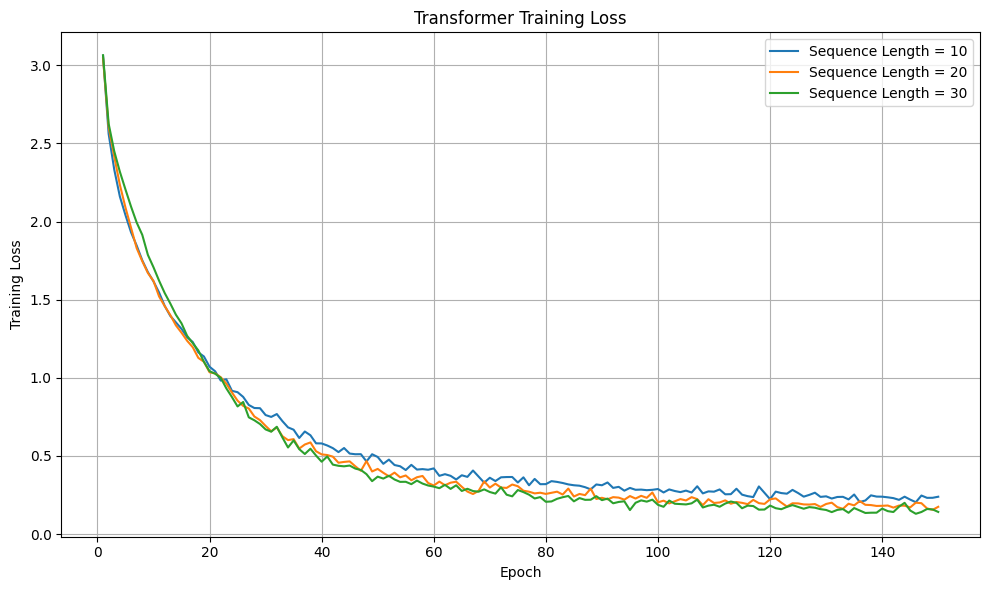

In [ ]:
plt.figure(figsize=(10, 6))

for sequence_length in SEQUENCE_LENGTHS:
    history = experiment_outputs[
        sequence_length
    ]["history"]

    epochs = range(
        1,
        len(history["training_loss"]) + 1
    )

    plt.plot(
        epochs,
        history["training_loss"],
        label=f"Sequence Length = {sequence_length}"
    )

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Transformer Training Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(
    "problem1_training_loss.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

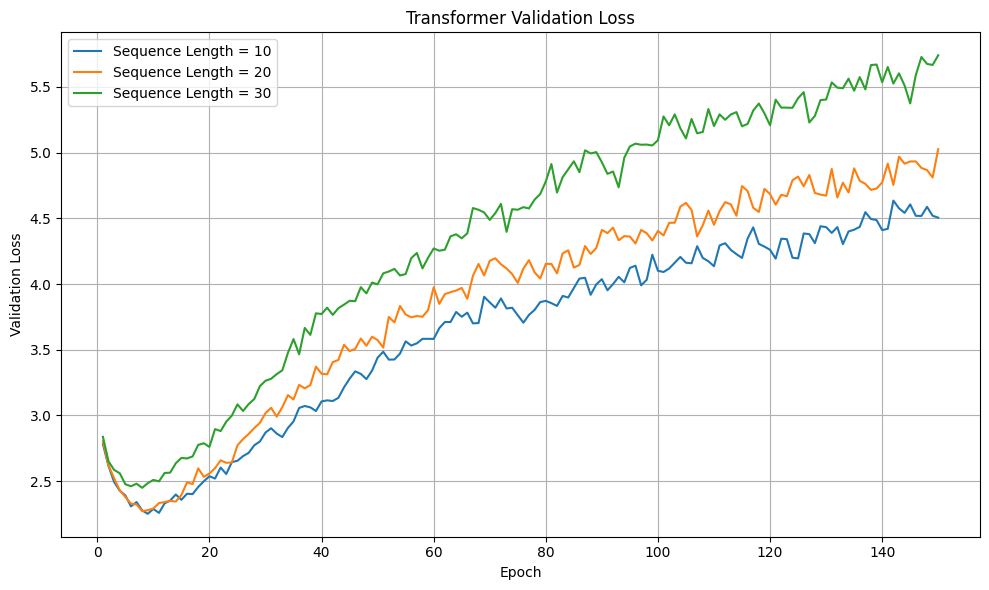

In [ ]:
plt.figure(figsize=(10, 6))

for sequence_length in SEQUENCE_LENGTHS:
    history = experiment_outputs[
        sequence_length
    ]["history"]

    epochs = range(
        1,
        len(history["validation_loss"]) + 1
    )

    plt.plot(
        epochs,
        history["validation_loss"],
        label=f"Sequence Length = {sequence_length}"
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Transformer Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(
    "problem1_validation_loss.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

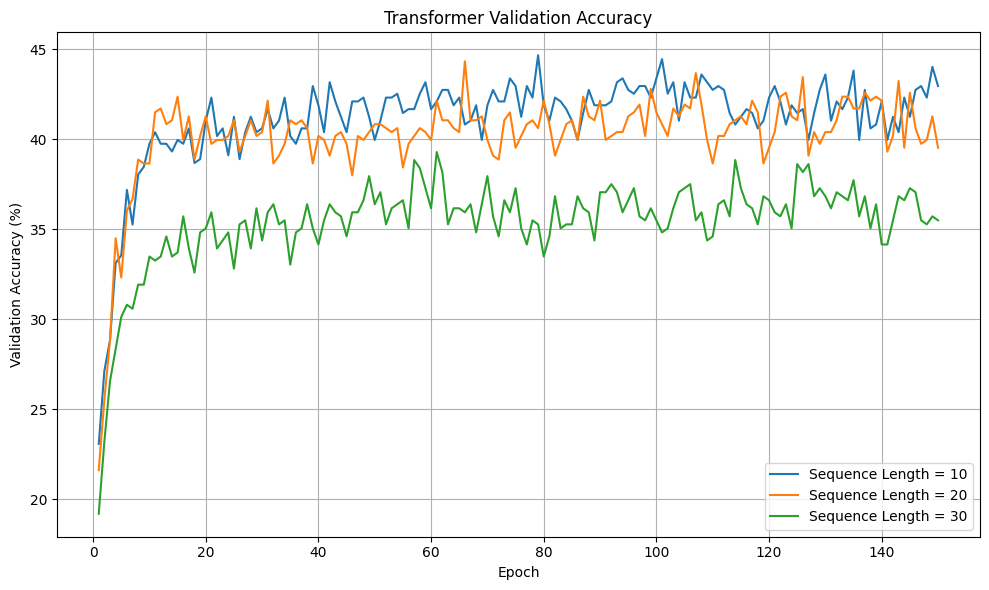

In [ ]:
plt.figure(figsize=(10, 6))

for sequence_length in SEQUENCE_LENGTHS:
    history = experiment_outputs[
        sequence_length
    ]["history"]

    validation_accuracy_percent = [
        accuracy * 100
        for accuracy in history["validation_accuracy"]
    ]

    epochs = range(
        1,
        len(validation_accuracy_percent) + 1
    )

    plt.plot(
        epochs,
        validation_accuracy_percent,
        label=f"Sequence Length = {sequence_length}"
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Transformer Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(
    "problem1_validation_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

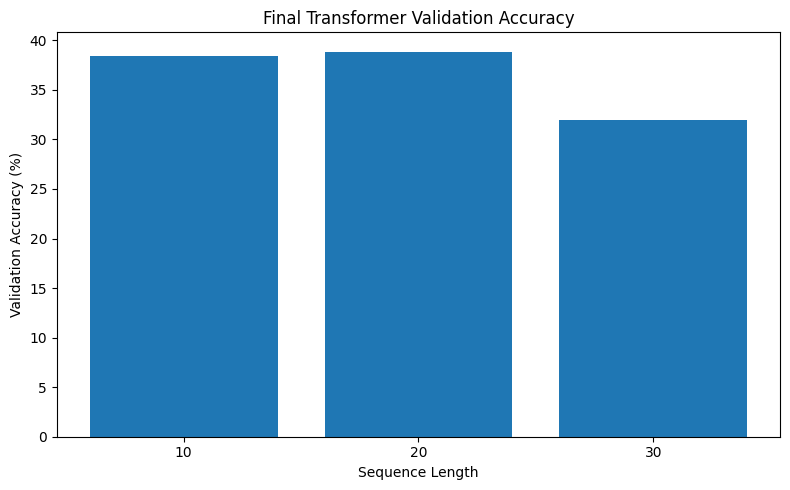

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    summary_df["Sequence Length"].astype(str),
    summary_df["Validation Accuracy (%)"]
)

plt.xlabel("Sequence Length")
plt.ylabel("Validation Accuracy (%)")
plt.title("Final Transformer Validation Accuracy")
plt.tight_layout()
plt.savefig(
    "problem1_final_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

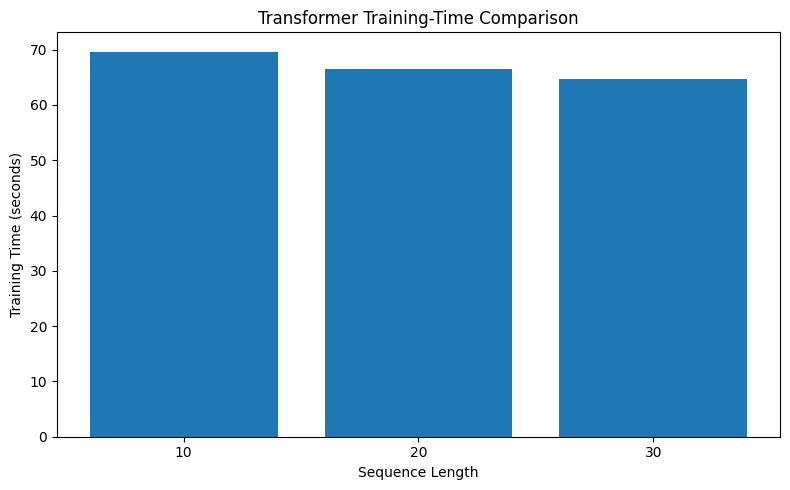

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    summary_df["Sequence Length"].astype(str),
    summary_df["Training Time (s)"]
)

plt.xlabel("Sequence Length")
plt.ylabel("Training Time (seconds)")
plt.title("Transformer Training-Time Comparison")
plt.tight_layout()
plt.savefig(
    "problem1_training_time_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

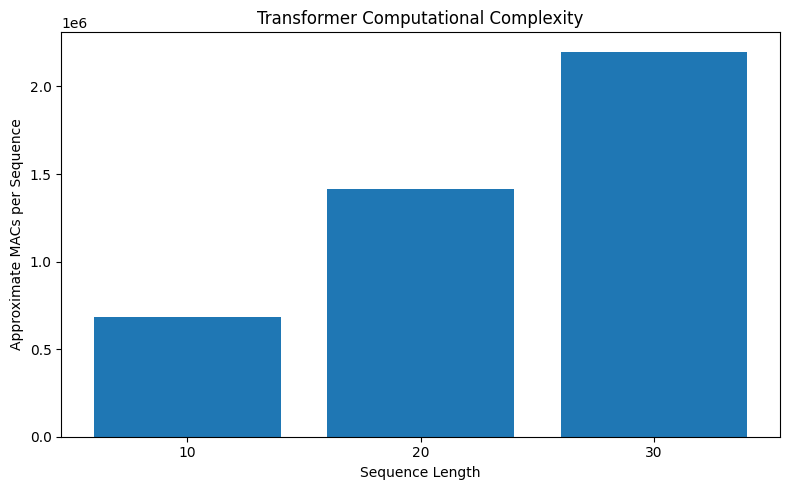

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    summary_df["Sequence Length"].astype(str),
    summary_df["Approximate MACs"]
)

plt.xlabel("Sequence Length")
plt.ylabel("Approximate MACs per Sequence")
plt.title("Transformer Computational Complexity")
plt.tight_layout()
plt.savefig(
    "problem1_complexity_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
@torch.no_grad()
def predict_next_character(
    model,
    context,
    sequence_length
):
    model.eval()

    context = context[-sequence_length:]

    if len(context) < sequence_length:
        raise ValueError(
            f"The context must contain at least "
            f"{sequence_length} characters."
        )

    encoded_context = torch.tensor(
        [
            char_to_index[character]
            for character in context
        ],
        dtype=torch.long
    ).unsqueeze(0).to(device)

    logits = model(encoded_context)

    predicted_index = logits.argmax(dim=1).item()

    return index_to_char[predicted_index]

In [ ]:
@torch.no_grad()
def display_validation_predictions(
    model,
    sequence_length,
    number_of_examples=10
):
    model.eval()

    validation_dataset = CharacterWindowDataset(
        validation_encoded,
        sequence_length
    )

    example_indices = np.linspace(
        0,
        len(validation_dataset) - 1,
        number_of_examples,
        dtype=int
    )

    rows = []

    for index in example_indices:
        input_sequence, target_character = (
            validation_dataset[index]
        )

        input_batch = (
            input_sequence
            .unsqueeze(0)
            .to(device)
        )

        logits = model(input_batch)

        predicted_index = logits.argmax(
            dim=1
        ).item()

        context = "".join(
            index_to_char[value.item()]
            for value in input_sequence
        )

        actual_character = index_to_char[
            target_character.item()
        ]

        predicted_character = index_to_char[
            predicted_index
        ]

        rows.append({
            "Context": context,
            "Actual Next Character": repr(actual_character),
            "Predicted Character": repr(predicted_character),
            "Correct": actual_character == predicted_character
        })

    return pd.DataFrame(rows)

In [ ]:
best_row_index = summary_df[
    "Validation Accuracy (%)"
].idxmax()

best_sequence_length = int(
    summary_df.loc[
        best_row_index,
        "Sequence Length"
    ]
)

best_model = experiment_outputs[
    best_sequence_length
]["model"]

print(
    "Best sequence length:",
    best_sequence_length
)

prediction_examples = display_validation_predictions(
    model=best_model,
    sequence_length=best_sequence_length,
    number_of_examples=10
)

prediction_examples

Best sequence length: 20


,Context,Actual Next Character,Predicted Character,Correct
0,"letion features, and",' ',' ',True
1,ons with AI-based ch,'a','a',True
2,"In summary, next cha",'r','r',True
3,al role in enhancing,' ',' ',True
4,"P applications, maki",'n','n',True
5,"e efficient, accurat",'e','i',False
6,use of advanced mach,'i','e',False
7,"nd LSTMs, next chara",'c','c',True
8,"olve, opening new po",'s','r',False
9,ext-based technology,'.',' ',False


In [ ]:
homework2_results = pd.DataFrame([
    {
        "Model": "RNN",
        "Sequence Length": 10,
        "Training Loss": 2.6699,
        "Validation Accuracy (%)": 22.96,
        "Training Time (s)": 0.338,
        "Inference Time (ms)": 0.572,
        "Parameters": 3805,
        "Model Size (MB)": 0.015,
        "Approximate MACs": 16800
    },
    {
        "Model": "LSTM",
        "Sequence Length": 10,
        "Training Loss": 2.8548,
        "Validation Accuracy (%)": 16.28,
        "Training Time (s)": 0.677,
        "Inference Time (ms)": 1.114,
        "Parameters": 8605,
        "Model Size (MB)": 0.033,
        "Approximate MACs": 62880
    },
    {
        "Model": "GRU",
        "Sequence Length": 10,
        "Training Loss": 2.6542,
        "Validation Accuracy (%)": 21.29,
        "Training Time (s)": 0.511,
        "Inference Time (ms)": 1.023,
        "Parameters": 7005,
        "Model Size (MB)": 0.027,
        "Approximate MACs": 47520
    },
    {
        "Model": "RNN",
        "Sequence Length": 20,
        "Training Loss": 2.6470,
        "Validation Accuracy (%)": 22.13,
        "Training Time (s)": 0.430,
        "Inference Time (ms)": 0.850,
        "Parameters": 3805,
        "Model Size (MB)": 0.015,
        "Approximate MACs": 32160
    },
    {
        "Model": "LSTM",
        "Sequence Length": 20,
        "Training Loss": 2.7696,
        "Validation Accuracy (%)": 21.09,
        "Training Time (s)": 0.966,
        "Inference Time (ms)": 1.278,
        "Parameters": 8605,
        "Model Size (MB)": 0.033,
        "Approximate MACs": 124320
    },
    {
        "Model": "GRU",
        "Sequence Length": 20,
        "Training Loss": 2.7537,
        "Validation Accuracy (%)": 21.29,
        "Training Time (s)": 0.835,
        "Inference Time (ms)": 2.904,
        "Parameters": 7005,
        "Model Size (MB)": 0.027,
        "Approximate MACs": 93600
    },
    {
        "Model": "RNN",
        "Sequence Length": 30,
        "Training Loss": 2.6800,
        "Validation Accuracy (%)": 22.34,
        "Training Time (s)": 0.577,
        "Inference Time (ms)": 1.162,
        "Parameters": 3805,
        "Model Size (MB)": 0.015,
        "Approximate MACs": 47520
    },
    {
        "Model": "LSTM",
        "Sequence Length": 30,
        "Training Loss": 2.8112,
        "Validation Accuracy (%)": 19.21,
        "Training Time (s)": 1.171,
        "Inference Time (ms)": 1.840,
        "Parameters": 8605,
        "Model Size (MB)": 0.033,
        "Approximate MACs": 185760
    },
    {
        "Model": "GRU",
        "Sequence Length": 30,
        "Training Loss": 2.7691,
        "Validation Accuracy (%)": 22.34,
        "Training Time (s)": 1.147,
        "Inference Time (ms)": 3.668,
        "Parameters": 7005,
        "Model Size (MB)": 0.027,
        "Approximate MACs": 139680
    }
])

homework2_results

,Model,Sequence Length,Training Loss,Validation Accuracy (%),Training Time (s),Inference Time (ms),Parameters,Model Size (MB),Approximate MACs
0,RNN,10,2.6699,22.96,0.338,0.572,3805,0.015,16800
1,LSTM,10,2.8548,16.28,0.677,1.114,8605,0.033,62880
2,GRU,10,2.6542,21.29,0.511,1.023,7005,0.027,47520
3,RNN,20,2.6470,22.13,0.430,0.850,3805,0.015,32160
4,LSTM,20,2.7696,21.09,0.966,1.278,8605,0.033,124320
5,GRU,20,2.7537,21.29,0.835,2.904,7005,0.027,93600
6,RNN,30,2.6800,22.34,0.577,1.162,3805,0.015,47520
7,LSTM,30,2.8112,19.21,1.171,1.840,8605,0.033,185760
8,GRU,30,2.7691,22.34,1.147,3.668,7005,0.027,139680


In [ ]:
transformer_comparison = summary_df[[
    "Model",
    "Sequence Length",
    "Training Loss",
    "Validation Accuracy (%)",
    "Training Time (s)",
    "Inference Time (ms)",
    "Parameters",
    "Model Size (MB)",
    "Approximate MACs"
]].copy()

complete_comparison = pd.concat(
    [transformer_comparison, homework2_results],
    ignore_index=True
)

complete_comparison.round({
    "Training Loss": 4,
    "Validation Accuracy (%)": 2,
    "Training Time (s)": 3,
    "Inference Time (ms)": 3,
    "Model Size (MB)": 3
})

,Model,Sequence Length,Training Loss,Validation Accuracy (%),Training Time (s),Inference Time (ms),Parameters,Model Size (MB),Approximate MACs
0,Transformer,10,1.4411,38.46,69.659,0.791,75948,0.300,683776
1,Transformer,20,1.4968,38.86,66.580,0.867,75948,0.300,1415936
2,Transformer,30,1.6783,31.92,64.740,0.786,75948,0.300,2199296
3,RNN,10,2.6699,22.96,0.338,0.572,3805,0.015,16800
4,LSTM,10,2.8548,16.28,0.677,1.114,8605,0.033,62880
5,GRU,10,2.6542,21.29,0.511,1.023,7005,0.027,47520
6,RNN,20,2.6470,22.13,0.430,0.850,3805,0.015,32160
7,LSTM,20,2.7696,21.09,0.966,1.278,8605,0.033,124320
8,GRU,20,2.7537,21.29,0.835,2.904,7005,0.027,93600
9,RNN,30,2.6800,22.34,0.577,1.162,3805,0.015,47520


In [ ]:
complete_comparison.to_csv(
    "problem1_transformer_vs_homework2.csv",
    index=False
)

print("Saved: problem1_transformer_vs_homework2.csv")

Saved: problem1_transformer_vs_homework2.csv


In [ ]:
best_homework2_by_length = (
    homework2_results
    .sort_values(
        "Validation Accuracy (%)",
        ascending=False
    )
    .groupby(
        "Sequence Length",
        as_index=False
    )
    .first()
)

best_homework2_by_length

,Sequence Length,Model,Training Loss,Validation Accuracy (%),Training Time (s),Inference Time (ms),Parameters,Model Size (MB),Approximate MACs
0,10,RNN,2.6699,22.96,0.338,0.572,3805,0.015,16800
1,20,RNN,2.6470,22.13,0.430,0.850,3805,0.015,32160
2,30,GRU,2.7691,22.34,1.147,3.668,7005,0.027,139680


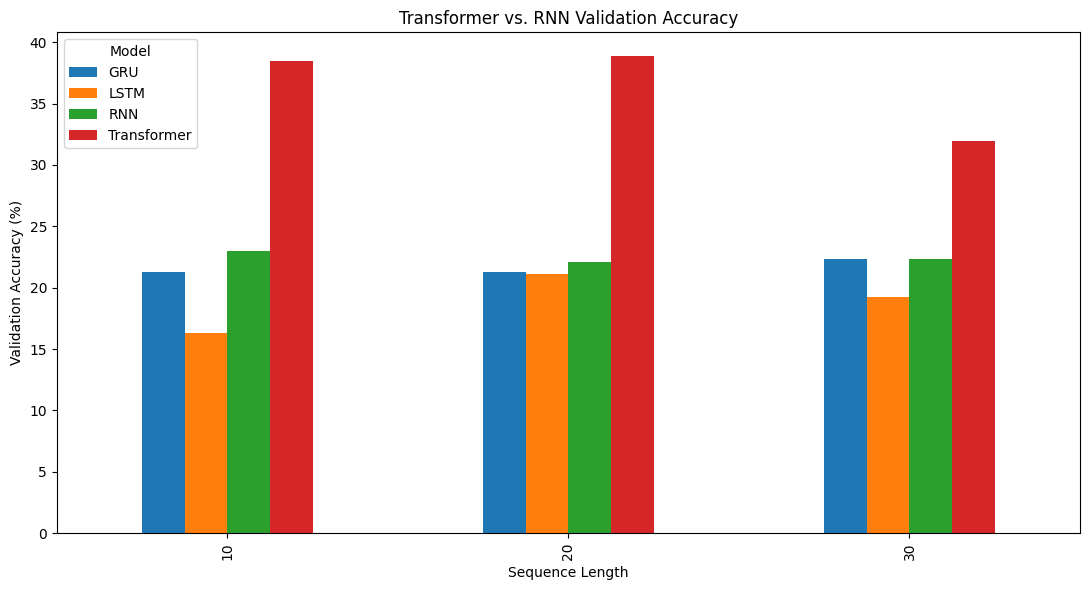

In [ ]:
accuracy_pivot = complete_comparison.pivot(
    index="Sequence Length",
    columns="Model",
    values="Validation Accuracy (%)"
)

accuracy_pivot.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.xlabel("Sequence Length")
plt.ylabel("Validation Accuracy (%)")
plt.title("Transformer vs. RNN Validation Accuracy")
plt.legend(title="Model")
plt.tight_layout()
plt.savefig(
    "problem1_transformer_vs_rnn_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
import os
import shutil

OUTPUT_FOLDER = "problem1_results"
ZIP_NAME = "problem1_results"

# Remove an older results folder if this cell was already run.
if os.path.exists(OUTPUT_FOLDER):
    shutil.rmtree(OUTPUT_FOLDER)

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# Collect all Problem 1 output files.
output_files = [
    filename
    for filename in os.listdir(".")
    if filename.startswith("problem1_")
    and os.path.isfile(filename)
    and not filename.endswith(".zip")
]

for filename in output_files:
    shutil.copy(
        filename,
        os.path.join(OUTPUT_FOLDER, filename)
    )

# Remove an older ZIP file before creating a new one.
zip_path = f"{ZIP_NAME}.zip"

if os.path.exists(zip_path):
    os.remove(zip_path)

shutil.make_archive(
    ZIP_NAME,
    "zip",
    OUTPUT_FOLDER
)

print(f"Created: {zip_path}")
print("\nFiles included:")

for filename in sorted(output_files):
    print(" -", filename)

Created: problem1_results.zip

Files included:
 - problem1_complexity_comparison.png
 - problem1_final_accuracy_comparison.png
 - problem1_training_loss.png
 - problem1_training_time_comparison.png
 - problem1_transformer_results.csv
 - problem1_transformer_vs_homework2.csv
 - problem1_transformer_vs_rnn_accuracy.png
 - problem1_validation_accuracy.png
 - problem1_validation_loss.png


In [ ]:
from google.colab import files

files.download("problem1_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>